## 一、微积分与梯度计算专题：从导数到反向传播

### 一、知识框架总览

整个体系可以用一条主线串联：**标量函数的导数 → 多变量函数的偏导数与梯度 → 向量函数的雅可比矩阵 → 复合函数的链式法则 → 神经网络中的反向传播**。每一层都是前一层的自然延伸。

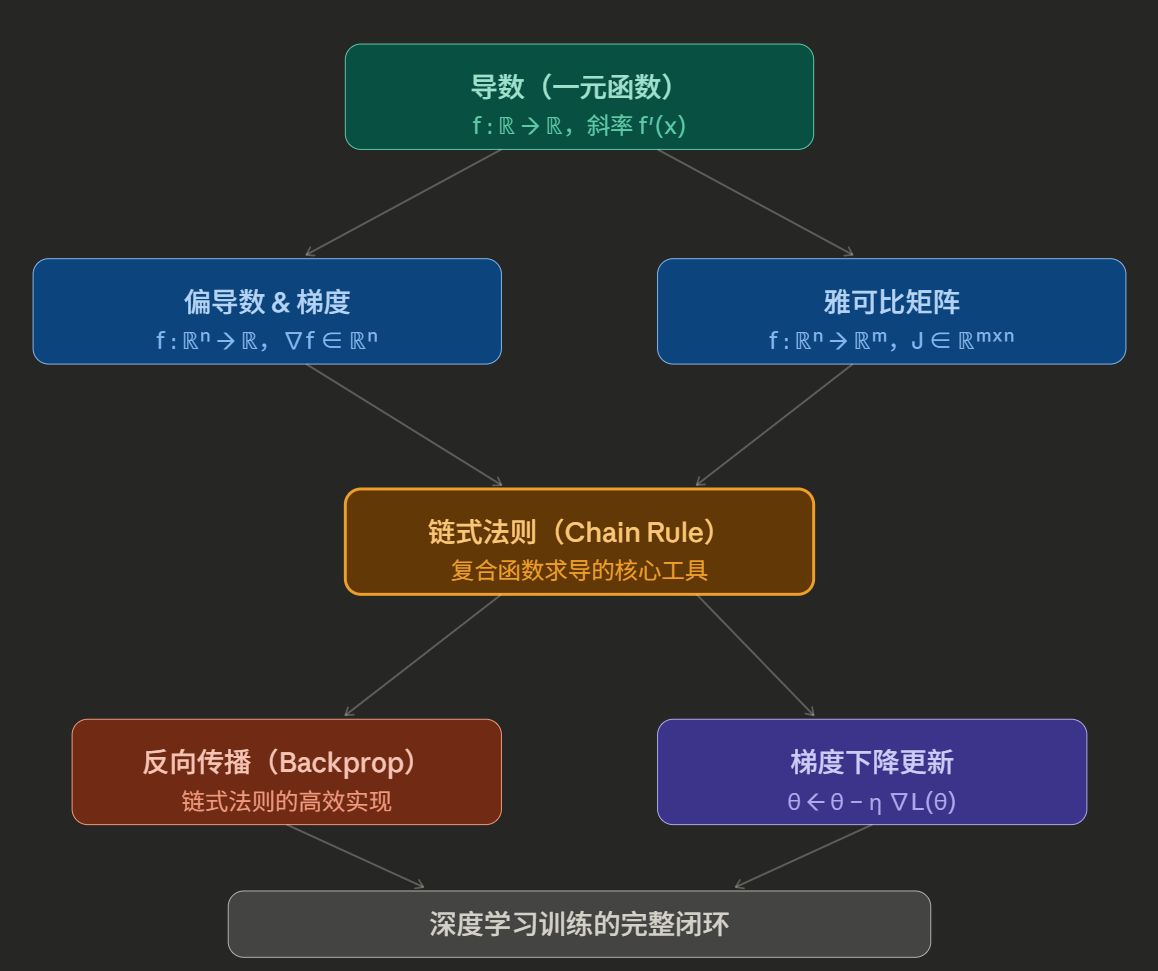

---

### 二、第一层：导数（一元函数）

#### 2.1 本质是什么？

导数描述的是函数在某一点处的**局部变化率**——当自变量变化极小量 $\Delta x$ 时，因变量变化了多少。形式定义为：

$$f'(x) = \lim_{\Delta x \to 0} \frac{f(x + \Delta x) - f(x)}{\Delta x}$$

几何上，$f'(x)$ 就是曲线在 $x$ 处切线的斜率。梯度下降中"沿梯度反方向走"，本质依赖的就是这个量。

#### 2.2 必须烂熟于心的基本求导公式

以下是深度学习中真实会用到的：

$$\frac{d}{dx} x^n = n x^{n-1} \qquad \frac{d}{dx} e^x = e^x \qquad \frac{d}{dx} \ln x = \frac{1}{x}$$

$$\frac{d}{dx} \sigma(x) = \sigma(x)(1-\sigma(x)) \qquad \frac{d}{dx} \tanh(x) = 1 - \tanh^2(x)$$

$$\frac{d}{dx} \text{ReLU}(x) = \begin{cases}1 & x > 0 \\ 0 & x < 0\end{cases}$$

**sigmoid 的导数推导**是面试高频考点，值得显式推一遍：

$$\sigma(x) = \frac{1}{1+e^{-x}}$$

令 $u = 1 + e^{-x}$，则 $\sigma = u^{-1}$，用链式法则：

$$\sigma'(x) = -u^{-2} \cdot (-e^{-x}) = \frac{e^{-x}}{(1+e^{-x})^2} = \frac{1}{1+e^{-x}} \cdot \frac{e^{-x}}{1+e^{-x}} = \sigma(x)(1-\sigma(x))$$

---

### 三、第二层：偏导数与梯度（多变量函数）

#### 3.1 从一元扩展到多元

当函数有多个输入时，比如 $f(x_1, x_2)$，就不能只谈"导数"了——需要知道沿**每个方向**各自的变化率。**偏导数**就是在固定其他变量不动的情况下，对某一个变量求导：

$$\frac{\partial f}{\partial x_1} = \lim_{\Delta x_1 \to 0} \frac{f(x_1 + \Delta x_1, x_2) - f(x_1, x_2)}{\Delta x_1}$$

计算时，把其他变量当作常数，剩余的求导规则与一元完全相同。

**具体例子**：$f(x_1, x_2) = x_1^2 + 3x_1 x_2 + x_2^3$

$$\frac{\partial f}{\partial x_1} = 2x_1 + 3x_2 \qquad \frac{\partial f}{\partial x_2} = 3x_1 + 3x_2^2$$

#### 3.2 梯度：将所有偏导数打包成向量

**梯度**就是把所有偏导数收集成一个列向量，记作 $\nabla f$。对于 $f: \mathbb{R}^n \to \mathbb{R}$（输入是 $n$ 维向量，输出是一个标量），梯度为：

$$\nabla f(\mathbf{x}) = \begin{bmatrix} \frac{\partial f}{\partial x_1} \\ \frac{\partial f}{\partial x_2} \\ \vdots \\ \frac{\partial f}{\partial x_n} \end{bmatrix} \in \mathbb{R}^n$$

梯度的几何含义：**它指向函数值增长最快的方向**，其模长代表最快增长的速率。梯度下降之所以沿**负梯度方向**更新，正是因为这个原因——负梯度是下降最快的方向。

**梯度下降更新规则**（向量形式）：

$$\mathbf{x}_{t+1} = \mathbf{x}_t - \eta \nabla f(\mathbf{x}_t)$$

---

### 四、第三层：雅可比矩阵（向量函数）

#### 4.1 它解决什么问题？

梯度处理的是"多输入、单输出"函数（$\mathbb{R}^n \to \mathbb{R}$）。但神经网络中大量的操作是"多输入、多输出"（$\mathbb{R}^n \to \mathbb{R}^m$），比如一个全连接层将 $n$ 维输入映射到 $m$ 维输出。这时就需要**雅可比矩阵**来完整描述所有偏导数关系。

#### 4.2 定义

对于 $\mathbf{f}: \mathbb{R}^n \to \mathbb{R}^m$，即：

$$\mathbf{f}(\mathbf{x}) = \begin{bmatrix} f_1(x_1,\ldots,x_n) \\ f_2(x_1,\ldots,x_n) \\ \vdots \\ f_m(x_1,\ldots,x_n) \end{bmatrix}$$

雅可比矩阵 $J \in \mathbb{R}^{m \times n}$ 的第 $i$ 行第 $j$ 列元素为：

$$J_{ij} = \frac{\partial f_i}{\partial x_j}$$

展开写：

$$J = \begin{bmatrix} \frac{\partial f_1}{\partial x_1} & \frac{\partial f_1}{\partial x_2} & \cdots & \frac{\partial f_1}{\partial x_n} \\ \frac{\partial f_2}{\partial x_1} & \frac{\partial f_2}{\partial x_2} & \cdots & \frac{\partial f_2}{\partial x_n} \\ \vdots & & \ddots & \vdots \\ \frac{\partial f_m}{\partial x_1} & \frac{\partial f_m}{\partial x_2} & \cdots & \frac{\partial f_m}{\partial x_n} \end{bmatrix}$$

**直觉**：$J$ 的第 $i$ 行告诉你"第 $i$ 个输出如何随所有输入变化"；第 $j$ 列告诉你"第 $j$ 个输入变化时，所有输出如何响应"。

#### 4.3 具体例子：一个全连接层

设 $\mathbf{y} = W\mathbf{x}$，其中 $W \in \mathbb{R}^{m \times n}$，$\mathbf{x} \in \mathbb{R}^n$，$\mathbf{y} \in \mathbb{R}^m$。则：

$$y_i = \sum_{j=1}^n W_{ij} x_j \implies \frac{\partial y_i}{\partial x_j} = W_{ij}$$

所以这个线性映射的雅可比矩阵就是 $W$ 本身，即 $J = W$。这在反向传播推导中非常重要。

#### 4.4 梯度是雅可比的特例

当 $m=1$ 时，$\mathbf{f}$ 退化为标量函数 $f$，雅可比矩阵退化为 $1 \times n$ 的行向量，其转置就是梯度 $\nabla f$。三者的关系可以这样理解：

$$\text{导数（}n=1,m=1\text{）} \subset \text{梯度（}m=1\text{）} \subset \text{雅可比（一般情形）}$$

---

### 五、第四层：链式法则

#### 5.1 为什么链式法则如此关键？

神经网络本质是**复合函数的嵌套**：输入经过线性变换，再经过激活函数，再经过线性变换……最终输出损失。要对最初的参数 $W$ 求导，就必须将这条"计算链"从后往前逐层拆解，这正是链式法则的用武之地。

#### 5.2 一元版本

若 $y = f(g(x))$，令 $u = g(x)$，则：

$$\frac{dy}{dx} = \frac{dy}{du} \cdot \frac{du}{dx} = f'(g(x)) \cdot g'(x)$$

**例**：求 $y = e^{x^2}$ 的导数。令 $u = x^2$，则 $y = e^u$：

$$\frac{dy}{dx} = e^u \cdot 2x = 2x e^{x^2}$$

#### 5.3 多元版本（全微分形式）

若 $z = f(u, v)$，而 $u = g(x)$，$v = h(x)$，则：

$$\frac{dz}{dx} = \frac{\partial z}{\partial u} \cdot \frac{du}{dx} + \frac{\partial z}{\partial v} \cdot \frac{dv}{dx}$$

**原理**：$x$ 的变化通过 $u$ 和 $v$ 两条路径影响 $z$，最终效果是两条路径贡献之和。这个"路径累加"的思想贯穿整个反向传播。

#### 5.4 向量版本（矩阵形式）

若 $\mathbf{z} = f(\mathbf{y})$，$\mathbf{y} = g(\mathbf{x})$，则复合函数的雅可比为：

$$\frac{\partial \mathbf{z}}{\partial \mathbf{x}} = \frac{\partial \mathbf{z}}{\partial \mathbf{y}} \cdot \frac{\partial \mathbf{y}}{\partial \mathbf{x}} = J_f \cdot J_g$$

其中 $J_f \in \mathbb{R}^{p \times m}$，$J_g \in \mathbb{R}^{m \times n}$，结果为 $\mathbb{R}^{p \times n}$。这就是为什么说"反向传播是矩阵乘法的链式展开"。

---

### 六、第五层：反向传播

反向传播是链式法则在计算图上的**高效实现策略**。理解它需要先建立"计算图"的概念。

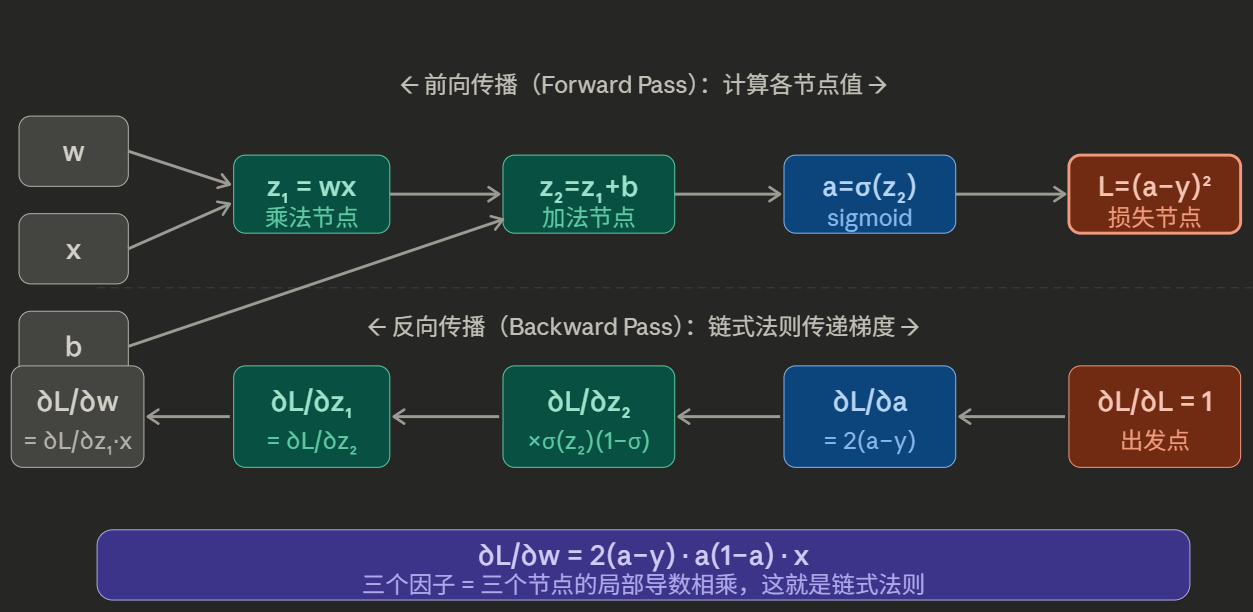

#### 6.1 计算图

将一次前向计算拆解成有向无环图（DAG），每个节点是一个基本运算。以 $L = (\sigma(wx + b) - y)^2$ 为例：

#### 6.2 逐步数值计算示例

用具体数值走一遍完整的前向 + 反向过程，设 $w=2, x=1, b=0, y=0.8$。

**前向传播**（从左到右计算各节点值）：

$$z_1 = wx = 2 \times 1 = 2$$
$$z_2 = z_1 + b = 2 + 0 = 2$$
$$a = \sigma(z_2) = \frac{1}{1+e^{-2}} \approx 0.8808$$
$$L = (a - y)^2 = (0.8808 - 0.8)^2 \approx 0.00653$$

**反向传播**（从右到左，链式法则逐层传递）：

$$\frac{\partial L}{\partial L} = 1 \quad \text{（出发点，恒为 1）}$$

$$\frac{\partial L}{\partial a} = 2(a - y) = 2 \times 0.0808 \approx 0.1616$$

$$\frac{\partial L}{\partial z_2} = \frac{\partial L}{\partial a} \cdot \frac{\partial a}{\partial z_2} = 0.1616 \times a(1-a) = 0.1616 \times 0.8808 \times 0.1192 \approx 0.01697$$

$$\frac{\partial L}{\partial z_1} = \frac{\partial L}{\partial z_2} \cdot \underbrace{\frac{\partial z_2}{\partial z_1}}_{=1} = 0.01697 \quad \text{（加法节点，梯度直接通过）}$$

$$\frac{\partial L}{\partial w} = \frac{\partial L}{\partial z_1} \cdot \underbrace{\frac{\partial z_1}{\partial w}}_{=x} = 0.01697 \times 1 = 0.01697$$

$$\frac{\partial L}{\partial b} = \frac{\partial L}{\partial z_2} \cdot 1 = 0.01697$$

参数更新（$\eta = 0.1$）：

$$w \leftarrow 2 - 0.1 \times 0.01697 = 1.9983$$

#### 6.3 两类节点的局部导数规律

理解了计算图，反向传播的核心就浓缩成对每个基本节点记住其"局部导数"：

**加法节点**：$z = x + y$，则 $\frac{\partial z}{\partial x} = 1$，$\frac{\partial z}{\partial y} = 1$。梯度原封不动地向两个输入分发，称为**梯度分发器**。

**乘法节点**：$z = x \cdot y$，则 $\frac{\partial z}{\partial x} = y$，$\frac{\partial z}{\partial y} = x$。梯度乘以**对方的值**传回，两路互换，称为**梯度交换器**。

**激活函数节点**：$z = \sigma(x)$，则 $\frac{\partial z}{\partial x} = \sigma(x)(1-\sigma(x))$，梯度乘以当前激活值的导数后传回。

**矩阵乘法节点**：$\mathbf{y} = W\mathbf{x}$，设上游传来梯度 $\delta = \frac{\partial L}{\partial \mathbf{y}}$，则：

$$\frac{\partial L}{\partial \mathbf{x}} = W^T \delta \qquad \frac{\partial L}{\partial W} = \delta \mathbf{x}^T$$

这里雅可比矩阵的作用就显现了：对 $\mathbf{x}$ 的梯度是 $W$ 转置乘以上游梯度，对 $W$ 的梯度是上游梯度与输入的外积。

---

### 七、全局知识框架总结

以下将所有概念的输入输出形状、计算方式和应用场景整理成一张对照表：

| 概念 | 函数类型 | 输出形状 | 梯度/导数计算 | 在深度学习中出现的场景 |
|---|---|---|---|---|
| 导数 $f'(x)$ | $\mathbb{R} \to \mathbb{R}$ | 标量 | 极限定义或查表 | 单个激活函数节点的局部导数 |
| 偏导数 $\frac{\partial f}{\partial x_i}$ | $\mathbb{R}^n \to \mathbb{R}$ | 标量 | 固定其他变量求导 | 对某个权重的损失敏感度 |
| 梯度 $\nabla f$ | $\mathbb{R}^n \to \mathbb{R}$ | $n$ 维向量 | 所有偏导数打包 | 参数更新的方向和步幅 |
| 雅可比矩阵 $J$ | $\mathbb{R}^n \to \mathbb{R}^m$ | $m \times n$ 矩阵 | $J_{ij} = \frac{\partial f_i}{\partial x_j}$ | 全连接层、激活层的梯度反传 |
| 链式法则 | 复合函数 | 同上游输出 | 局部导数相乘/矩阵连乘 | 多层网络反向传播的核心公式 |
| 反向传播 | 计算图 | 每层的梯度 | 从输出向输入动态规划 | 所有深度学习框架的训练引擎 |

**一个关键的形状验证原则**：在反向传播中，某个参数的梯度形状必须与该参数本身的形状完全一致。若 $W \in \mathbb{R}^{m \times n}$，则 $\frac{\partial L}{\partial W}$ 也必须是 $m \times n$ 的矩阵。遇到形状对不上，往往意味着某处转置漏写或矩阵乘法顺序有误。这个验证习惯能帮你在推导时快速定位错误。


### 一、多层网络的参数更新顺序

在多层网络中，参数更新遵循严格的"先完整反传、后统一更新"流程，而非逐层算完立即更新。具体分为三个阶段。

**前向传播阶段**：输入数据从第一层流向最后一层，每个节点的中间值（激活值、线性变换结果等）全部被缓存，供反向传播使用。

**反向传播阶段**：从损失函数出发，依次计算 $\frac{\partial L}{\partial W_n}, \frac{\partial L}{\partial W_{n-1}}, \ldots, \frac{\partial L}{\partial W_1}$，所有层的梯度被完整计算并存储，但此时参数尚未改变。这一阶段之所以必须算完对中间变量（包括每层输入 $x$）的梯度，正是因为第 $k$ 层对 $W_k$ 的梯度，依赖于第 $k+1$ 层传回来的上游梯度 $\frac{\partial L}{\partial z_{k+1}}$；而该上游梯度恰恰是通过对第 $k$ 层输出求导得到的。换言之，每一层的"输入梯度"是下一层梯度计算的原材料，缺少任何一环，整条链式法则便无法连通。

**统一更新阶段**：所有梯度计算完毕后，执行一次梯度下降：

$$W_k \leftarrow W_k - \eta \cdot \frac{\partial L}{\partial W_k}, \quad k = 1, 2, \ldots, n$$

若在反向传播中途就修改参数，前向传播缓存的中间值将与当前参数不一致，导致后续层的梯度计算错误。这是标准深度学习框架（PyTorch、JAX 等）的统一实现逻辑。

---

### 二、Embedding 层的参数更新机制

Embedding 层在结构上是一个形状为 $|\mathcal{V}| \times d$ 的可学习矩阵，其中 $|\mathcal{V}|$ 为词表大小，$d$ 为嵌入维度。前向传播时，输入 token id 对应的行被"查出"作为当前输入向量；从网络的角度看，这等价于一次矩阵乘法 $\mathbf{h} = E[i, :]$，即取 Embedding 矩阵第 $i$ 行。

这里对输入求导的意义便得到了完整体现。若将原始离散输入理解为一个连续向量 $\mathbf{x}$（即 Embedding 矩阵中对应的行），则：

$$\frac{\partial L}{\partial \mathbf{x}} = \frac{\partial L}{\partial \mathbf{h}}$$

这个梯度的形状与 $\mathbf{x}$ 完全一致，因此可以直接用于更新 Embedding 矩阵中被访问的那些行。若本次 batch 中出现了 3 个 token，每个 token 以 4 维向量表示，则输入矩阵 $x \in \mathbb{R}^{3 \times 4}$，反向传播算出的 $\frac{\partial L}{\partial x} \in \mathbb{R}^{3 \times 4}$，两者形状精确对应，只有本次出现过的 3 行会被更新，其余词表行梯度为零、保持不变。

这正是"对 $x$ 求导"在实际系统中最重要的应用场景之一——它将离散符号的查表操作，转化为一个可微的连续优化问题，使得词向量能够通过梯度下降端到端地学习。

---

### 三、小矩阵完整计算示例

以下以一个两层全连接网络为例，$x \in \mathbb{R}^{2 \times 3}$ 表示 2 个样本、每个样本 3 维特征（即 batch size = 2），网络结构为：

$$x \in \mathbb{R}^{2\times3} \xrightarrow{W_1 \in \mathbb{R}^{3\times2}} Z \in \mathbb{R}^{2\times2} \xrightarrow{W_2 \in \mathbb{R}^{2\times1}} \hat{y} \in \mathbb{R}^{2\times1} \longrightarrow L$$

设定具体数值：

$$x = \begin{bmatrix}1 & 2 & 0\\ 0 & 1 & 3\end{bmatrix}, \quad W_1 = \begin{bmatrix}1 & 0\\ -1 & 1\\ 0 & 2\end{bmatrix}, \quad W_2 = \begin{bmatrix}1\\ -1\end{bmatrix}, \quad y_{\text{true}} = \begin{bmatrix}1\\ 0\end{bmatrix}$$

**前向传播：**

$$Z = x W_1 = \begin{bmatrix}1&2&0\\0&1&3\end{bmatrix}\begin{bmatrix}1&0\\-1&1\\0&2\end{bmatrix} = \begin{bmatrix}1\cdot1+2\cdot(-1)+0\cdot0 & 1\cdot0+2\cdot1+0\cdot2\\ 0\cdot1+1\cdot(-1)+3\cdot0 & 0\cdot0+1\cdot1+3\cdot2\end{bmatrix} = \begin{bmatrix}-1 & 2\\ -1 & 7\end{bmatrix}$$

$$\hat{y} = Z W_2 = \begin{bmatrix}-1&2\\-1&7\end{bmatrix}\begin{bmatrix}1\\-1\end{bmatrix} = \begin{bmatrix}-3\\-8\end{bmatrix}$$

$$L = \frac{1}{2}\|\hat{y} - y\|^2 = \frac{1}{2}\left[(-3-1)^2 + (-8-0)^2\right] = \frac{1}{2}(16 + 64) = 40$$

**反向传播（链式法则逐层展开）：**

**第一步**，损失对 $\hat{y}$ 的梯度（$\in \mathbb{R}^{2\times1}$）：

$$\frac{\partial L}{\partial \hat{y}} = \hat{y} - y = \begin{bmatrix}-3\\-8\end{bmatrix} - \begin{bmatrix}1\\0\end{bmatrix} = \begin{bmatrix}-4\\-8\end{bmatrix}$$

**第二步**，对 $W_2$ 求梯度（$\in \mathbb{R}^{2\times1}$，与 $W_2$ 形状一致）：

$$\frac{\partial L}{\partial W_2} = Z^T \cdot \frac{\partial L}{\partial \hat{y}} = \begin{bmatrix}-1&-1\\2&7\end{bmatrix}\begin{bmatrix}-4\\-8\end{bmatrix} = \begin{bmatrix}(-1)(-4)+(-1)(-8)\\ 2(-4)+7(-8)\end{bmatrix} = \begin{bmatrix}12\\ -64\end{bmatrix}$$

**第三步**，梯度向前传递，计算对 $Z$ 的梯度（$\in \mathbb{R}^{2\times2}$，与 $Z$ 形状一致）：

$$\frac{\partial L}{\partial Z} = \frac{\partial L}{\partial \hat{y}} \cdot W_2^T = \begin{bmatrix}-4\\-8\end{bmatrix}\begin{bmatrix}1 & -1\end{bmatrix} = \begin{bmatrix}-4 & 4\\ -8 & 8\end{bmatrix}$$

**第四步**，对 $W_1$ 求梯度（$\in \mathbb{R}^{3\times2}$，与 $W_1$ 形状一致）：

$$\frac{\partial L}{\partial W_1} = x^T \cdot \frac{\partial L}{\partial Z} = \begin{bmatrix}1&0\\2&1\\0&3\end{bmatrix}\begin{bmatrix}-4&4\\-8&8\end{bmatrix} = \begin{bmatrix}-4&4\\-16&16\\-24&24\end{bmatrix}$$

**第五步**，对 $x$ 求梯度（$\in \mathbb{R}^{2\times3}$，与 $x$ 形状一致；若 $x$ 为 Embedding，此梯度用于更新对应行）：

$$\frac{\partial L}{\partial x} = \frac{\partial L}{\partial Z} \cdot W_1^T = \begin{bmatrix}-4&4\\-8&8\end{bmatrix}\begin{bmatrix}1&-1&0\\0&1&2\end{bmatrix} = \begin{bmatrix}-4&8&8\\-8&16&16\end{bmatrix}$$

**参数更新**（$\eta = 0.01$）：

$$W_2 \leftarrow \begin{bmatrix}1\\-1\end{bmatrix} - 0.01\begin{bmatrix}12\\-64\end{bmatrix} = \begin{bmatrix}0.88\\-0.36\end{bmatrix}$$

$$W_1 \leftarrow \begin{bmatrix}1&0\\-1&1\\0&2\end{bmatrix} - 0.01\begin{bmatrix}-4&4\\-16&16\\-24&24\end{bmatrix} = \begin{bmatrix}1.04&-0.04\\-0.84&0.84\\0.24&1.76\end{bmatrix}$$

---

### 四、两个通用公式与记忆方式

对于任意全连接层 $Y = XW$，其中 $X \in \mathbb{R}^{B \times n}$，$W \in \mathbb{R}^{n \times m}$，$Y \in \mathbb{R}^{B \times m}$，设上游传来的梯度为 $\Delta = \frac{\partial L}{\partial Y} \in \mathbb{R}^{B \times m}$，两个核心公式为：

$$\frac{\partial L}{\partial W} = X^T \Delta \qquad \frac{\partial L}{\partial X} = \Delta W^T$$

记忆方式只需抓住一个原则：**谁是"另一侧"，梯度就乘谁**。对 $W$ 求导时，$W$ 的"另一侧"是 $X$，所以乘 $X^T$；对 $X$ 求导时，$X$ 的"另一侧"是 $W$，所以乘 $W^T$。加转置的原因并非约定，而是链式法则展开后求和结构的自然结果——前向传播用 $W$ 将 $n$ 维映射到 $m$ 维，反向传播则需要 $W^T$ 将梯度从 $m$ 维映射回 $n$ 维，方向对称，形状自洽。

验证时只需检查形状：$X^T \in \mathbb{R}^{n \times B}$ 乘以 $\Delta \in \mathbb{R}^{B \times m}$，结果为 $\mathbb{R}^{n \times m}$，与 $W$ 一致；$\Delta \in \mathbb{R}^{B \times m}$ 乘以 $W^T \in \mathbb{R}^{m \times n}$，结果为 $\mathbb{R}^{B \times n}$，与 $X$ 一致。形状验证是推导正确性的最快检验手段，建议作为推导习惯固化下来。

---

## 二、机器学习与深度学习优化算法体系专题

### 摘要 (Abstract)

在机器学习与深度学习领域，优化算法的目标是寻找模型参数 $\theta$，使得损失函数 $L(\theta)$ 最小化。根据求解策略的不同，优化算法可划分为**解析法（Analytical Methods）**与**数值分析法（Numerical Methods）**。解析法追求通过数学闭式解（Closed-form Solution）一步到位，但在深度学习的高维非线性空间中受限于计算复杂度和非凸性。数值分析法则通过迭代逼近，从二阶牛顿法降维到一阶梯度下降（GD），并演化出动量（Momentum）与自适应（Adaptive）等变体。本文将系统性地梳理这一体系，阐述各阶段算法的演进动机与应用场景。



### 一、 优化算法体系概览

优化算法的底层逻辑在于如何处理目标函数的导数信息（梯度）。其分类标准主要依据是否依赖迭代过程以及利用了几阶导数信息。

| 分类层级 | 求解策略 | 核心逻辑 | 典型算法 |
| :--- | :--- | :--- | :--- |
| **解析法** | 闭式求解 | 令 $\nabla L(\theta) = 0$ 直接求根 | 正规方程 (Normal Equation), KKT 条件 |
| **数值分析法** | 迭代搜索 | $\theta_{t+1} = \theta_t + \Delta \theta$ 逐步逼近 | 梯度下降, 牛顿法, 拟牛顿法 |

### 二、 解析法：理论基石及其局限性

解析法的核心在于利用微积分原理，通过代数变换直接锁定平稳点。

#### 2.1 典型应用：正规方程 (Normal Equation)
对于线性回归模型 $y = X\theta + \epsilon$，其最小二乘损失函数的解析解为：
$$\theta = (X^TX)^{-1}X^Ty$$

#### 2.2 深度学习弃用解析法的原因
1.  **非线性障碍**：神经网络中的激活函数（ReLU, Sigmoid）使得损失函数的导数方程成为复杂的超越方程，不存在代数闭式解。
2.  **计算复杂度**：矩阵求逆 $(X^TX)^{-1}$ 的复杂度为 $O(M^3)$，$M$ 为参数量。在千万级参数的模型中，内存与算力均无法支撑。
3.  **秩亏损与病态矩阵**：高维数据常导致 $X^TX$ 不可逆或条件数过大，导致数值解极不稳定。

### 三、 数值分析法：从二阶到一阶的降维

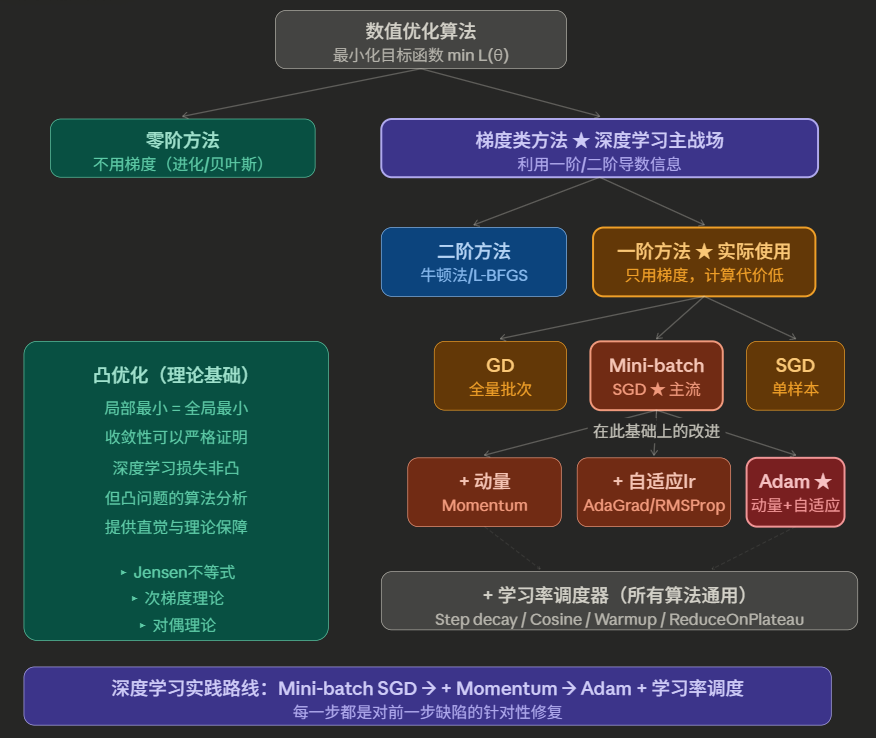

当无法通过解析法直接“看到”终点时，数值法选择在损失曲面上进行局部搜索。

#### 3.1 牛顿法（二阶数值法）
牛顿法利用二阶泰勒展开近似局部曲面：
$$\theta_{t+1} = \theta_t - H^{-1} \nabla L(\theta_t)$$
其中 $H$ 为 Hessian 矩阵。虽然收敛速度快（二阶收敛），但在深度学习中面临 **Hessian 存储成本 ($O(M^2)$)** 和 **计算逆矩阵代价** 巨大的问题，且极易陷入鞍点。

#### 3.2 梯度下降（一阶数值法）
为了适应大规模参数，深度学习退而求其次，仅利用一阶梯度信息：
$$\theta_{t+1} = \theta_t - \eta \nabla L(\theta_t)$$
其 $O(M)$ 的空间复杂度是神经网络得以训练的工程基础。

### 四、 深度学习优化器的演化路径

在进入具体算法之前，必须先理解深度学习的损失曲面与经典优化理论的核心差异。这三个挑战，直接驱动了后续每一个算法改进的动机。

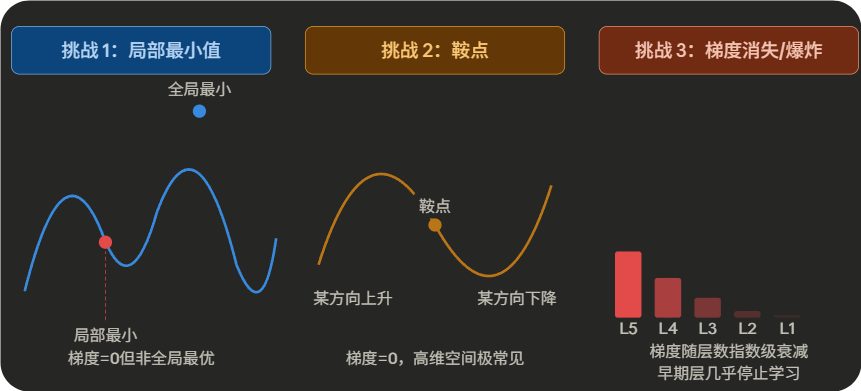

**凸优化的价值**正是在此处体现：凸函数保证"局部最小值就是全局最小值"，因此所有算法的收敛性可以被严格数学证明。深度学习损失函数虽然非凸，但研究者发现，在实践中大量的局部极小值质量相当接近全局最优（尤其是在高维空间中），真正危险的是鞍点和平坦区域。凸优化理论提供的直觉和算法框架，是分析非凸场景的基础语言。


以下逐步展示从原始梯度下降出发，每个算法如何针对性地修复前一个算法的缺陷，形成一条清晰的技术演进链。

#### 4.1 基础：批量梯度下降（GD）

每次用**全部训练样本**计算梯度，更新参数：

$$\theta \leftarrow \theta - \eta \cdot \frac{1}{N}\sum_{i=1}^{N} \nabla_\theta L_i(\theta)$$

缺陷是显而易见的：当数据集有百万条样本时，每更新一次参数就要遍历全部数据，计算代价极高，且无法实时响应数据分布的变化。

#### 4.2 修复计算代价：随机梯度下降（SGD）与 Mini-batch SGD

用**单个样本**（SGD）或**一小批样本**（Mini-batch SGD）的梯度近似替代全量梯度：

$$\theta \leftarrow \theta - \eta \cdot \nabla_\theta L_{i}(\theta) \quad \text{（随机取第 } i \text{ 个样本）}$$

Mini-batch SGD 是两者的折中，也是现代深度学习的实际标准。其中 batch size 的选取直接影响梯度估计的噪声水平和训练速度，通常取 32～512。

引入的新问题：梯度方向噪声大，在狭窄的"峡谷型"损失曲面中会剧烈震荡，收敛路径迂回。

#### 4.3 修复震荡问题：动量法（Momentum）

核心思想：给参数更新加入"惯性"，让历史梯度的方向也参与决策，而不是每步都完全跟随当前噪声梯度。

$$v_t = \beta v_{t-1} + (1-\beta)\nabla_\theta L(\theta) \qquad \theta \leftarrow \theta - \eta v_t$$

其中 $v_t$ 是梯度的指数加权移动平均，$\beta$ 通常取 0.9。效果相当于在"峡谷"中，横向震荡被历史动量相互抵消，纵向前进方向被不断累积放大，整体路径变得顺滑。

引入的新问题：所有参数共享同一个学习率 $\eta$，但实际情况中不同参数的梯度尺度差异巨大——稀疏特征（如 NLP 中的罕见词）出现频率低、梯度累积少，应当得到更大的更新步幅；高频特征则相反。

#### 4.4 修复学习率问题：AdaGrad / RMSProp

**AdaGrad** 为每个参数维护独立的累积梯度平方 $s_t$，并用它来缩放学习率：

$$s_t = s_{t-1} + g_t^2 \qquad \theta \leftarrow \theta - \frac{\eta}{\sqrt{s_t + \epsilon}} g_t$$

参数更新越频繁，$s_t$ 越大，有效学习率越小；冷门参数的 $s_t$ 较小，学习率较大，正好弥补了稀疏梯度的问题。

AdaGrad 的缺陷：$s_t$ 单调递增，训练后期有效学习率趋近于零，模型停止学习。

**RMSProp** 用指数加权移动平均替代历史梯度的全量累积，让 $s_t$ 保持动态：

$$s_t = \gamma s_{t-1} + (1-\gamma) g_t^2 \qquad \theta \leftarrow \theta - \frac{\eta}{\sqrt{s_t + \epsilon}} g_t$$

$\gamma$ 通常取 0.9，近期梯度的权重更高，$s_t$ 不再单调增长，修复了 AdaGrad 的过度衰减问题。

#### 4.5 终点：Adam（Adaptive Moment Estimation）

Adam 将 Momentum（一阶矩）与 RMSProp（二阶矩）合并到一个算法中，并加入偏差修正以消除训练初期动量估计的偏差：

$$m_t = \beta_1 m_{t-1} + (1-\beta_1) g_t \qquad \text{（一阶矩，动量）}$$

$$v_t = \beta_2 v_{t-1} + (1-\beta_2) g_t^2 \qquad \text{（二阶矩，自适应学习率）}$$

$$\hat{m}_t = \frac{m_t}{1-\beta_1^t} \qquad \hat{v}_t = \frac{v_t}{1-\beta_2^t} \qquad \text{（偏差修正）}$$

$$\theta \leftarrow \theta - \frac{\eta}{\sqrt{\hat{v}_t} + \epsilon} \hat{m}_t$$

默认超参数 $\beta_1 = 0.9$，$\beta_2 = 0.999$，$\epsilon = 10^{-8}$，$\eta = 10^{-3}$。Adam 在绝大多数任务上开箱即用，是工程首选。


### 五、 工程实践建议与常见误区

#### 5.1 决策框架
* **稀疏数据（如推荐系统 Embedding）**：首选 **Adam/AdaGrad**，利用其自适应特性处理低频特征。
* **计算机视觉（CV）精度追求**：首选 **SGD + Momentum**，虽然收敛慢，但其寻找的极小值通常更“平坦”，泛化性能更好。
* **大模型（NLP/Transformer）**：首选 **AdamW + Warmup**，确保训练初期的稳定性。

#### 5.2 核心误区提示
* **陷阱 1：梯度为 0 就是最优解**。在深度学习中，梯度为 0 的点极有可能是**鞍点**而非极小值点。
* **陷阱 2：学习率越小越稳**。过小的学习率会导致模型陷入局部平坦区域无法跳出，配合 **Cosine Annealing（余弦退火）** 往往比恒定学习率效果更好。
* **陷阱 3：Adam 优于一切**。Adam 在某些场景下存在不收敛或泛化差的问题，甚至可能不如经过精细调参的 SGD。

### 六、 小结

优化算法体系是从数学上的**解析精确解**向工程上的**数值近似解**妥协的过程。在深度学习中，我们通过放弃昂贵的二阶 Hessian 信息，转而使用高效的一阶梯度，并通过动量和自适应技术，在复杂的非凸高维空间中寻找“足够好”的局部最优解。理解这一演化过程，有助于我们在面对不同规模、不同稀疏度的数据集时，做出最合理的算法选择。

---

#### **举例子**

面试官给出 $y = \sigma(x)$（其中 $\sigma$ 为 sigmoid），已知 $y$，求 $x$。

这道题实际上有两层考法：

**考法 A（解析法）**：这个函数是单调可逆的，直接取 logit：

$$x = \ln\frac{y}{1-y}$$

**考法 B（梯度下降/函数逼近）**：假装不知道逆函数，把它转化为一个优化问题，用迭代法求解。面试官想考察的正是这个——你是否理解"逼近"的本质。

#### 如何用梯度下降求解？

**第一步：构造损失函数。** 将"找 $x$ 使 $\sigma(x) \approx y$"转化为最小化：

$$L(x) = \bigl(\sigma(x) - y\bigr)^2$$

**第二步：求梯度。** 对 $x$ 求导：

$$\frac{dL}{dx} = 2\bigl(\sigma(x) - y\bigr) \cdot \sigma(x)\bigl(1 - \sigma(x)\bigr)$$

其中 $\sigma'(x) = \sigma(x)(1-\sigma(x))$ 是 sigmoid 导数的经典结论，面试中必须能直接写出。

**第三步：梯度下降迭代。**

$$x_{t+1} = x_t - \eta \cdot \frac{dL}{dx}\bigg|_{x=x_t}$$

```python


In [11]:
import math

def sigmoid(x):
    return 1 / (1 + math.exp(-x))

def solve_by_gradient_descent(y_target, eta=0.1, steps=1501):
    x = 0.0  # 初始化（任意值均可，因为损失函数是凸的）
    for i in range(steps):
        sig = sigmoid(x)
        grad = 2 * (sig - y_target) * sig * (1 - sig)
        x -= eta * grad
        if i % 500 == 0:
            print(f"step {i:3d}: x={x:.6f}, σ(x)={sigmoid(x):.6f}, loss={( sigmoid(x)-y_target)**2:.2e}")
    return x

# 验证：令 y=0.8，解析解为 ln(0.8/0.2) = ln(4) ≈ 1.3863
x_solved = solve_by_gradient_descent(0.8)
print(f"\n解析解: {math.log(0.8/0.2):.6f}")
print(f"梯度下降解: {x_solved:.6f}")

step   0: x=0.015000, σ(x)=0.503750, loss=8.78e-02
step 500: x=1.338294, σ(x)=0.792209, loss=6.07e-05
step 1000: x=1.382751, σ(x)=0.799432, loss=3.22e-07
step 1500: x=1.386023, σ(x)=0.799957, loss=1.88e-09

解析解: 1.386294
梯度下降解: 1.386023
